In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

df['target'] = cancer.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(569, 31)


In [5]:
print(df.columns)
print(df.info())
print(df.describe())


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 

In [6]:
print(df.isnull().sum())


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [7]:
print(df['target'].value_counts())

1    357
0    212
Name: target, dtype: int64


Benign: 62.7%
Malignant: 37.3%
This is only a moderate imbalance

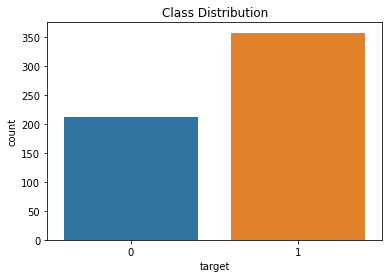

In [8]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()


In [9]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


Using Logistic Regression

In [13]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)


Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1 Score: 0.979020979020979


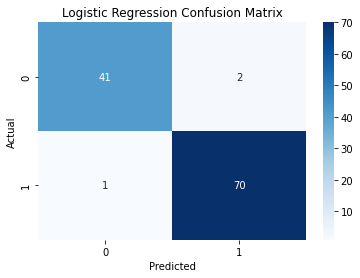

In [14]:
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy_log)
precision_log = precision_score(y_test, y_pred_log)
print("Precision:", precision_log)
recall_log = recall_score(y_test, y_pred_log)
print("Recall:", recall_log)
f1_log = f1_score(y_test, y_pred_log)
print("F1 Score:", f1_log)
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


The Logistic Regression model achieved an accuracy of 97.37%, with 97.22% precision, 98.59% recall, and an F1-score of 97.90%. These results indicate excellent classification performance and a high ability to correctly identify both benign and malignant tumors.

In [15]:
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



The classification report indicates consistently high precision, recall, and F1-scores for both classes, confirming that the Logistic Regression model performs reliably across benign and malignant cases.

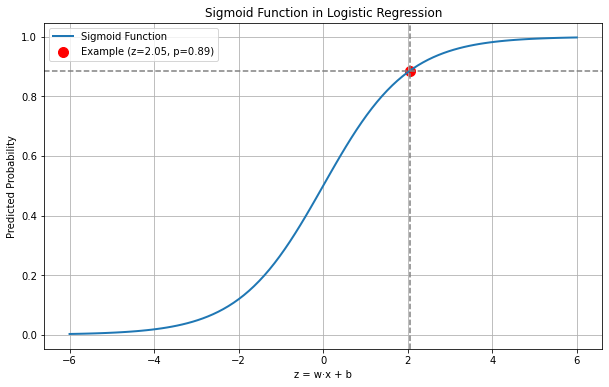

In [25]:
sample = X_test_scaled[0].reshape(1, -1)

# Compute z = w·x + b (decision function)
z = log_model.decision_function(sample)

# Compute probability using sigmoid
prob = 1 / (1 + np.exp(-z))

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate z values
z_values = np.linspace(-6, 6, 100)

# Calculate sigmoid values
sigmoid_probs = sigmoid(z_values)

# Plot
plt.figure(figsize=(10,6))
plt.plot(z_values, sigmoid_probs, linewidth=2, label='Sigmoid Function')

# Highlight example point
plt.scatter(z, prob,
            color='red',
            s=100,
            label=f'Example (z={z[0]:.2f}, p={prob[0]:.2f})')

plt.axvline(z[0], color='gray', linestyle='--')
plt.axhline(prob[0], color='gray', linestyle='--')

plt.xlabel("z = w·x + b")
plt.ylabel("Predicted Probability")
plt.title("Sigmoid Function in Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()


The sigmoid function converts the linear output of Logistic Regression into a probability between 0 and 1, enabling binary classification using a decision threshold.

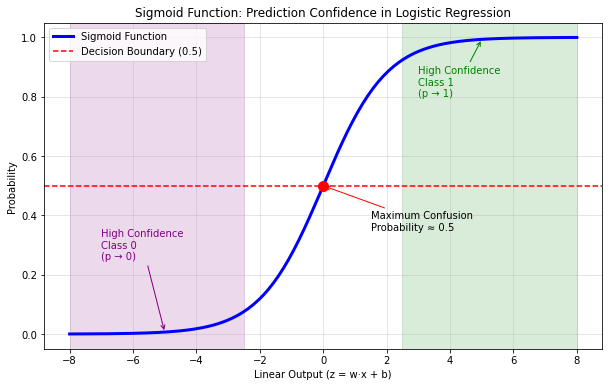

In [26]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Generate z values
z_values = np.linspace(-8, 8, 200)

# Calculate probabilities
probabilities = sigmoid(z_values)


plt.figure(figsize=(10,6))

# Sigmoid curve
plt.plot(z_values, probabilities,
         color='blue',
         linewidth=3,
         label="Sigmoid Function")


# Decision threshold
plt.axhline(y=0.5,
            color='red',
            linestyle='--',
            label="Decision Boundary (0.5)")


# High confidence zones
plt.axvspan(-8, -2.5,
            color='purple',
            alpha=0.15)

plt.axvspan(2.5, 8,
            color='green',
            alpha=0.15)


# Maximum confusion point
plt.scatter(0,0.5,
            color='red',
            s=100,
            zorder=5)

plt.annotate(
    "Maximum Confusion\nProbability ≈ 0.5",
    xy=(0,0.5),
    xytext=(1.5,0.35),
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)


# High confidence labels

plt.annotate(
    "High Confidence\nClass 0\n(p → 0)",
    xy=(-5, sigmoid(-5)),
    xytext=(-7,0.25),
    arrowprops=dict(
        arrowstyle="->",
        color="purple"
    ),
    color="purple"
)


plt.annotate(
    "High Confidence\nClass 1\n(p → 1)",
    xy=(5, sigmoid(5)),
    xytext=(3,0.8),
    arrowprops=dict(
        arrowstyle="->",
        color="green"
    ),
    color="green"
)


plt.xlabel("Linear Output (z = w·x + b)")
plt.ylabel("Probability")
plt.title("Sigmoid Function: Prediction Confidence in Logistic Regression")

plt.grid(alpha=0.4)
plt.legend()
plt.show()


Predictions with probabilities close to 0 or 1 represent high-confidence classifications.
The region around probability 0.5 represents maximum uncertainty because both classes have an equal likelihood of being predicted. Samples near this decision boundary/threshold have a higher chance of misclassification.

In [ ]:
# probabilities from the trained model
probs = log_model.predict_proba(X_test_scaled)[:,1]

# most uncertain sample
uncertain_index = np.argmin(abs(probs - 0.5))

print("Most uncertain sample probability:",
      probs[uncertain_index])


Most uncertain sample probability: 0.5132881101835551


In [ ]:
scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

best_k = scores.index(max(scores)) + 1
print("Best k:", best_k)


Best k: 9


The optimal value of k = 9 was selected based on model performance.

In [18]:
knn = KNeighborsClassifier(n_neighbors=9)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

Accuracy: 0.9649122807017544
Precision: 0.971830985915493
Recall: 0.971830985915493
F1 Score: 0.971830985915493


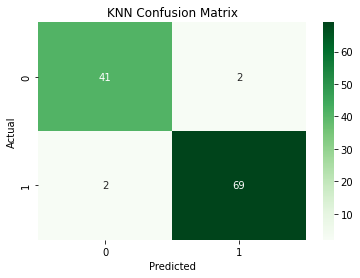

In [19]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)
precision_knn = precision_score(y_test, y_pred_knn)
print("Precision:", precision_knn)
recall_knn = recall_score(y_test, y_pred_knn)
print("Recall:", recall_knn)
f1_knn = f1_score(y_test, y_pred_knn)
print("F1 Score:", f1_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


The KNN classifier achieved an accuracy of 96.49%, with 97.18% precision, 97.18% recall, and an F1-score of 97.18%. The model demonstrated strong classification performance with only a slight reduction in accuracy compared to Logistic Regression.

In [20]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



The classification report shows balanced precision, recall, and F1-scores for both classes, indicating that the KNN model performs consistently on the test data.

In [21]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [accuracy_log, accuracy_knn],
    "Precision": [precision_log, precision_knn],
    "Recall": [recall_log, recall_knn],
    "F1 Score": [f1_log, f1_knn]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973684,0.972222,0.985915,0.979021
1,KNN,0.964912,0.971831,0.971831,0.971831


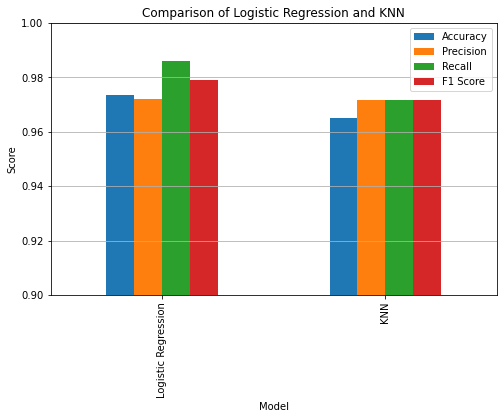

In [22]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of Logistic Regression and KNN")
plt.ylabel("Score")
plt.ylim(0.9, 1.0)
plt.grid(axis='y')
plt.show()


In [24]:
if accuracy_log > accuracy_knn:
    print("Logistic Regression performed better.")
elif accuracy_knn > accuracy_log:
    print("KNN performed better.")
else:
    print("Both models performed equally.")

print("Difference between both models: ", accuracy_log - accuracy_knn)


Logistic Regression performed better.
Difference between both models:  0.00877192982456143


Logistic Regression achieved a slightly higher accuracy (97.37%) than KNN (96.49%), along with higher recall (98.59%) and F1-score (97.90%).